# 02 — Two-hop WRITE / READ / CAUSAL core

This is the backbone analysis. The frozen corpus is screened once: the target answer must be clean top-1 and neither the concept nor its paired foil may appear in the clean top-10. The preregistered primary direction is raw $W_UJ$; the independently authored MD direction is evaluated on the fixed subset where both concepts exist. Every row stores signed per-layer/per-position WRITE and attribution READ, the exact first-order sum, real all-band ablation, a clean-clamped coordinate swap, and output-token suppression. Qwen-7B failed the strict spider top-1 gate in notebook 00, so these estimates are diagnostic rather than trusted main-scale evidence.

In [1]:
import json
import os
from pathlib import Path

ROOT = Path('/home/jovyan/j-space-thoughts')
os.chdir(ROOT)
os.environ['PIP_USER'] = 'false'
os.environ['PYTHONNOUSERSITE'] = '1'
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
prior = json.loads((ROOT / 'results/metrics.json').read_text())
print('G2 strict status carried forward:', prior['gates']['g2']['status'])
print('Independent MD validation carried forward:', prior['concept_vectors']['status'])

G2 strict status carried forward: FAIL
Independent MD validation carried forward: FAIL


## Frozen analysis variables

For P1, WRITE is mean absolute projection, READ is mean absolute $|\nabla_h M\cdot v|$, and CAUSAL is positive ablation damage $M_{clean}-M_{ablated}$. READ contains no WRITE term. Signed means and signed $\Delta M=M_{edited}-M_{clean}$ are analyzed separately. The product-derived support ratio is stored only as a diagnostic and excluded from P1, partial correlations, regressions, and headline figures. Bootstrap confidence intervals use 5,000 paired resamples.

In [2]:
from src.twohop_phase import run_qwen_twohop_phase

twohop = run_qwen_twohop_phase(
    model_id='Qwen/Qwen2.5-7B-Instruct',
    screen_batch_size=16,
    n_bootstrap=5000,
    fail_fast=False,
)

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

/opt/conda/lib/python3.11/site-packages/torch/autograd/graph.py:825: UserWarning: Flash Attention defaults to a non-deterministic algorithm. To explicitly enable determinism call torch.use_deterministic_algorithms(True, warn_only=False). (Triggered internally at ../aten/src/ATen/native/transformers/cuda/attention_backward.cu:102.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


TWO-HOP COMPUTED: eligible=155, rows=175/175, MD=20
TWO-HOP CORPUS PASS: N_clean_eligible=155 (required >=150); continuing either way.
Hypothesis verdict not auto-assigned; inspect reported estimates and CIs.


In [3]:
from src.metrics import save_json

metrics_path = ROOT / 'results/metrics.json'
metrics = json.loads(metrics_path.read_text())
metrics.setdefault('twohop', {})['qwen2.5-7b-instruct'] = twohop
save_json(metrics_path, metrics)
print('Curated per-item results merged into', metrics_path)

Curated per-item results merged into /home/jovyan/j-space-thoughts/results/metrics.json


In [4]:
import pandas as pd

def ci_row(label, value):
    if value.get('status') != 'ESTIMATED':
        return {'quantity': label, 'estimate': None, 'ci_low': None, 'ci_high': None, 'status': value.get('status')}
    return {'quantity': label, **{key: value[key] for key in ('estimate', 'ci_low', 'ci_high')}, 'status': value['status']}

rows = []
for method, stats in twohop['analyses']['ablation']['by_method'].items():
    rows.extend([
        ci_row(f'{method}: corr(CAUSAL, READ)', stats['pearson']['causal_vs_read']),
        ci_row(f'{method}: corr(CAUSAL, WRITE)', stats['pearson']['causal_vs_write']),
        ci_row(f'{method}: partial CAUSAL~READ|WRITE', stats['partial_correlations']['causal_read_given_write']),
        ci_row(f'{method}: partial CAUSAL~WRITE|READ', stats['partial_correlations']['causal_write_given_read']),
        ci_row(f'{method}: first-order vs real', stats['pearson']['predicted_vs_real']),
    ])
display(pd.DataFrame(rows))
display(pd.DataFrame(twohop['sample_counts']['n_by_method']).T)
errors = [row for row in twohop['rows'] if row['measurement_status'] != 'OK']
suppression = [abs(row['output_suppression']['concept']['delta']) for row in twohop['rows']]
print('Corpus criterion:', twohop['corpus_criterion'])
print('Measurement errors:', len(errors))
print('Maximum |output-suppression delta M|:', max(suppression) if suppression else None)

,quantity,estimate,ci_low,ci_high,status
0,"jlens_raw_wu_j: corr(CAUSAL, READ)",0.420430,0.241387,0.561821,ESTIMATED
1,"jlens_raw_wu_j: corr(CAUSAL, WRITE)",-0.040911,-0.194358,0.110523,ESTIMATED
2,jlens_raw_wu_j: partial CAUSAL~READ|WRITE,0.429913,0.265449,0.564904,ESTIMATED
3,jlens_raw_wu_j: partial CAUSAL~WRITE|READ,-0.107017,-0.249887,0.040031,ESTIMATED
4,jlens_raw_wu_j: first-order vs real,0.608368,0.513813,0.694565,ESTIMATED
5,"mean_difference: corr(CAUSAL, READ)",-0.087466,-0.531805,0.318423,ESTIMATED
6,"mean_difference: corr(CAUSAL, WRITE)",-0.436861,-0.721490,0.025728,ESTIMATED
7,mean_difference: partial CAUSAL~READ|WRITE,0.010130,-0.498589,0.459523,ESTIMATED
8,mean_difference: partial CAUSAL~WRITE|READ,-0.429760,-0.737394,0.118240,ESTIMATED
9,mean_difference: first-order vs real,0.551594,0.044529,0.833656,ESTIMATED


,assigned,successful
jlens_raw_wu_j,155,155
mean_difference,20,20


Corpus criterion: {'criterion': 'n_clean_eligible >= 150', 'threshold': 150, 'n_clean_eligible': 155, 'status': 'PASS', 'raises_on_failure': False}
Measurement errors: 0
Maximum |output-suppression delta M|: 0.0


F1 results/figures/f1_twohop_qwen2.5-7b.png


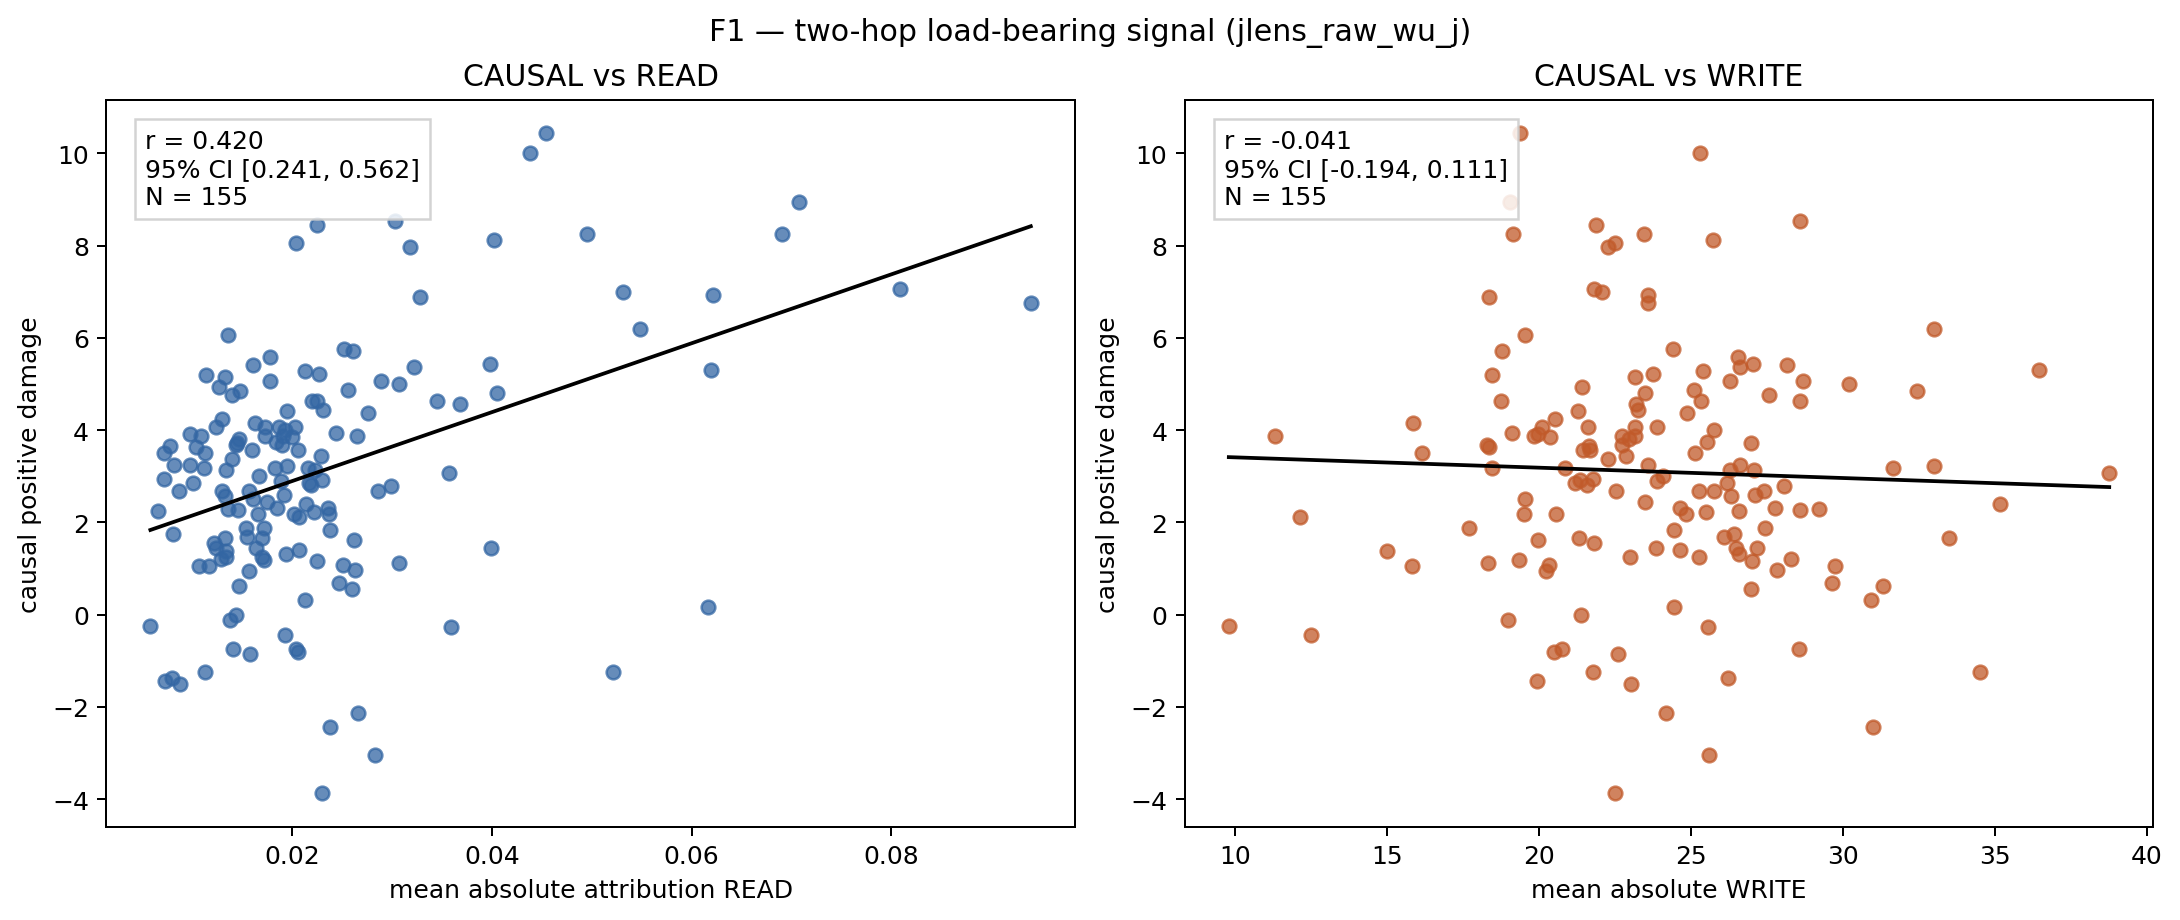

F2 results/figures/f2_twohop_qwen2.5-7b.png


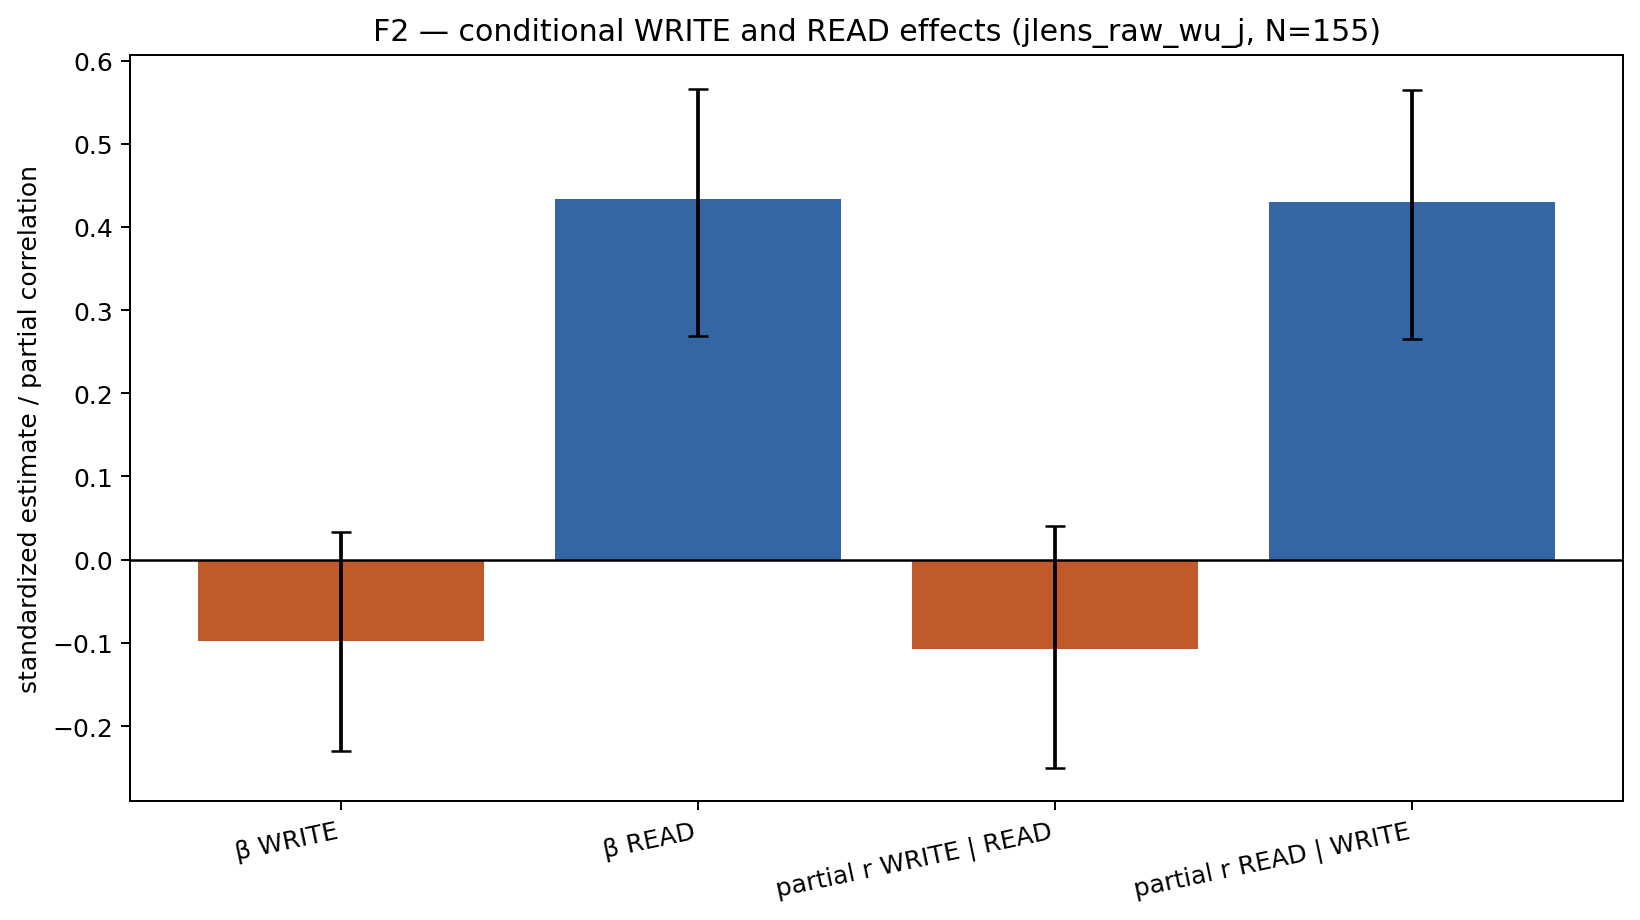

F6 results/figures/f6_direction_robustness_qwen2.5-7b.png


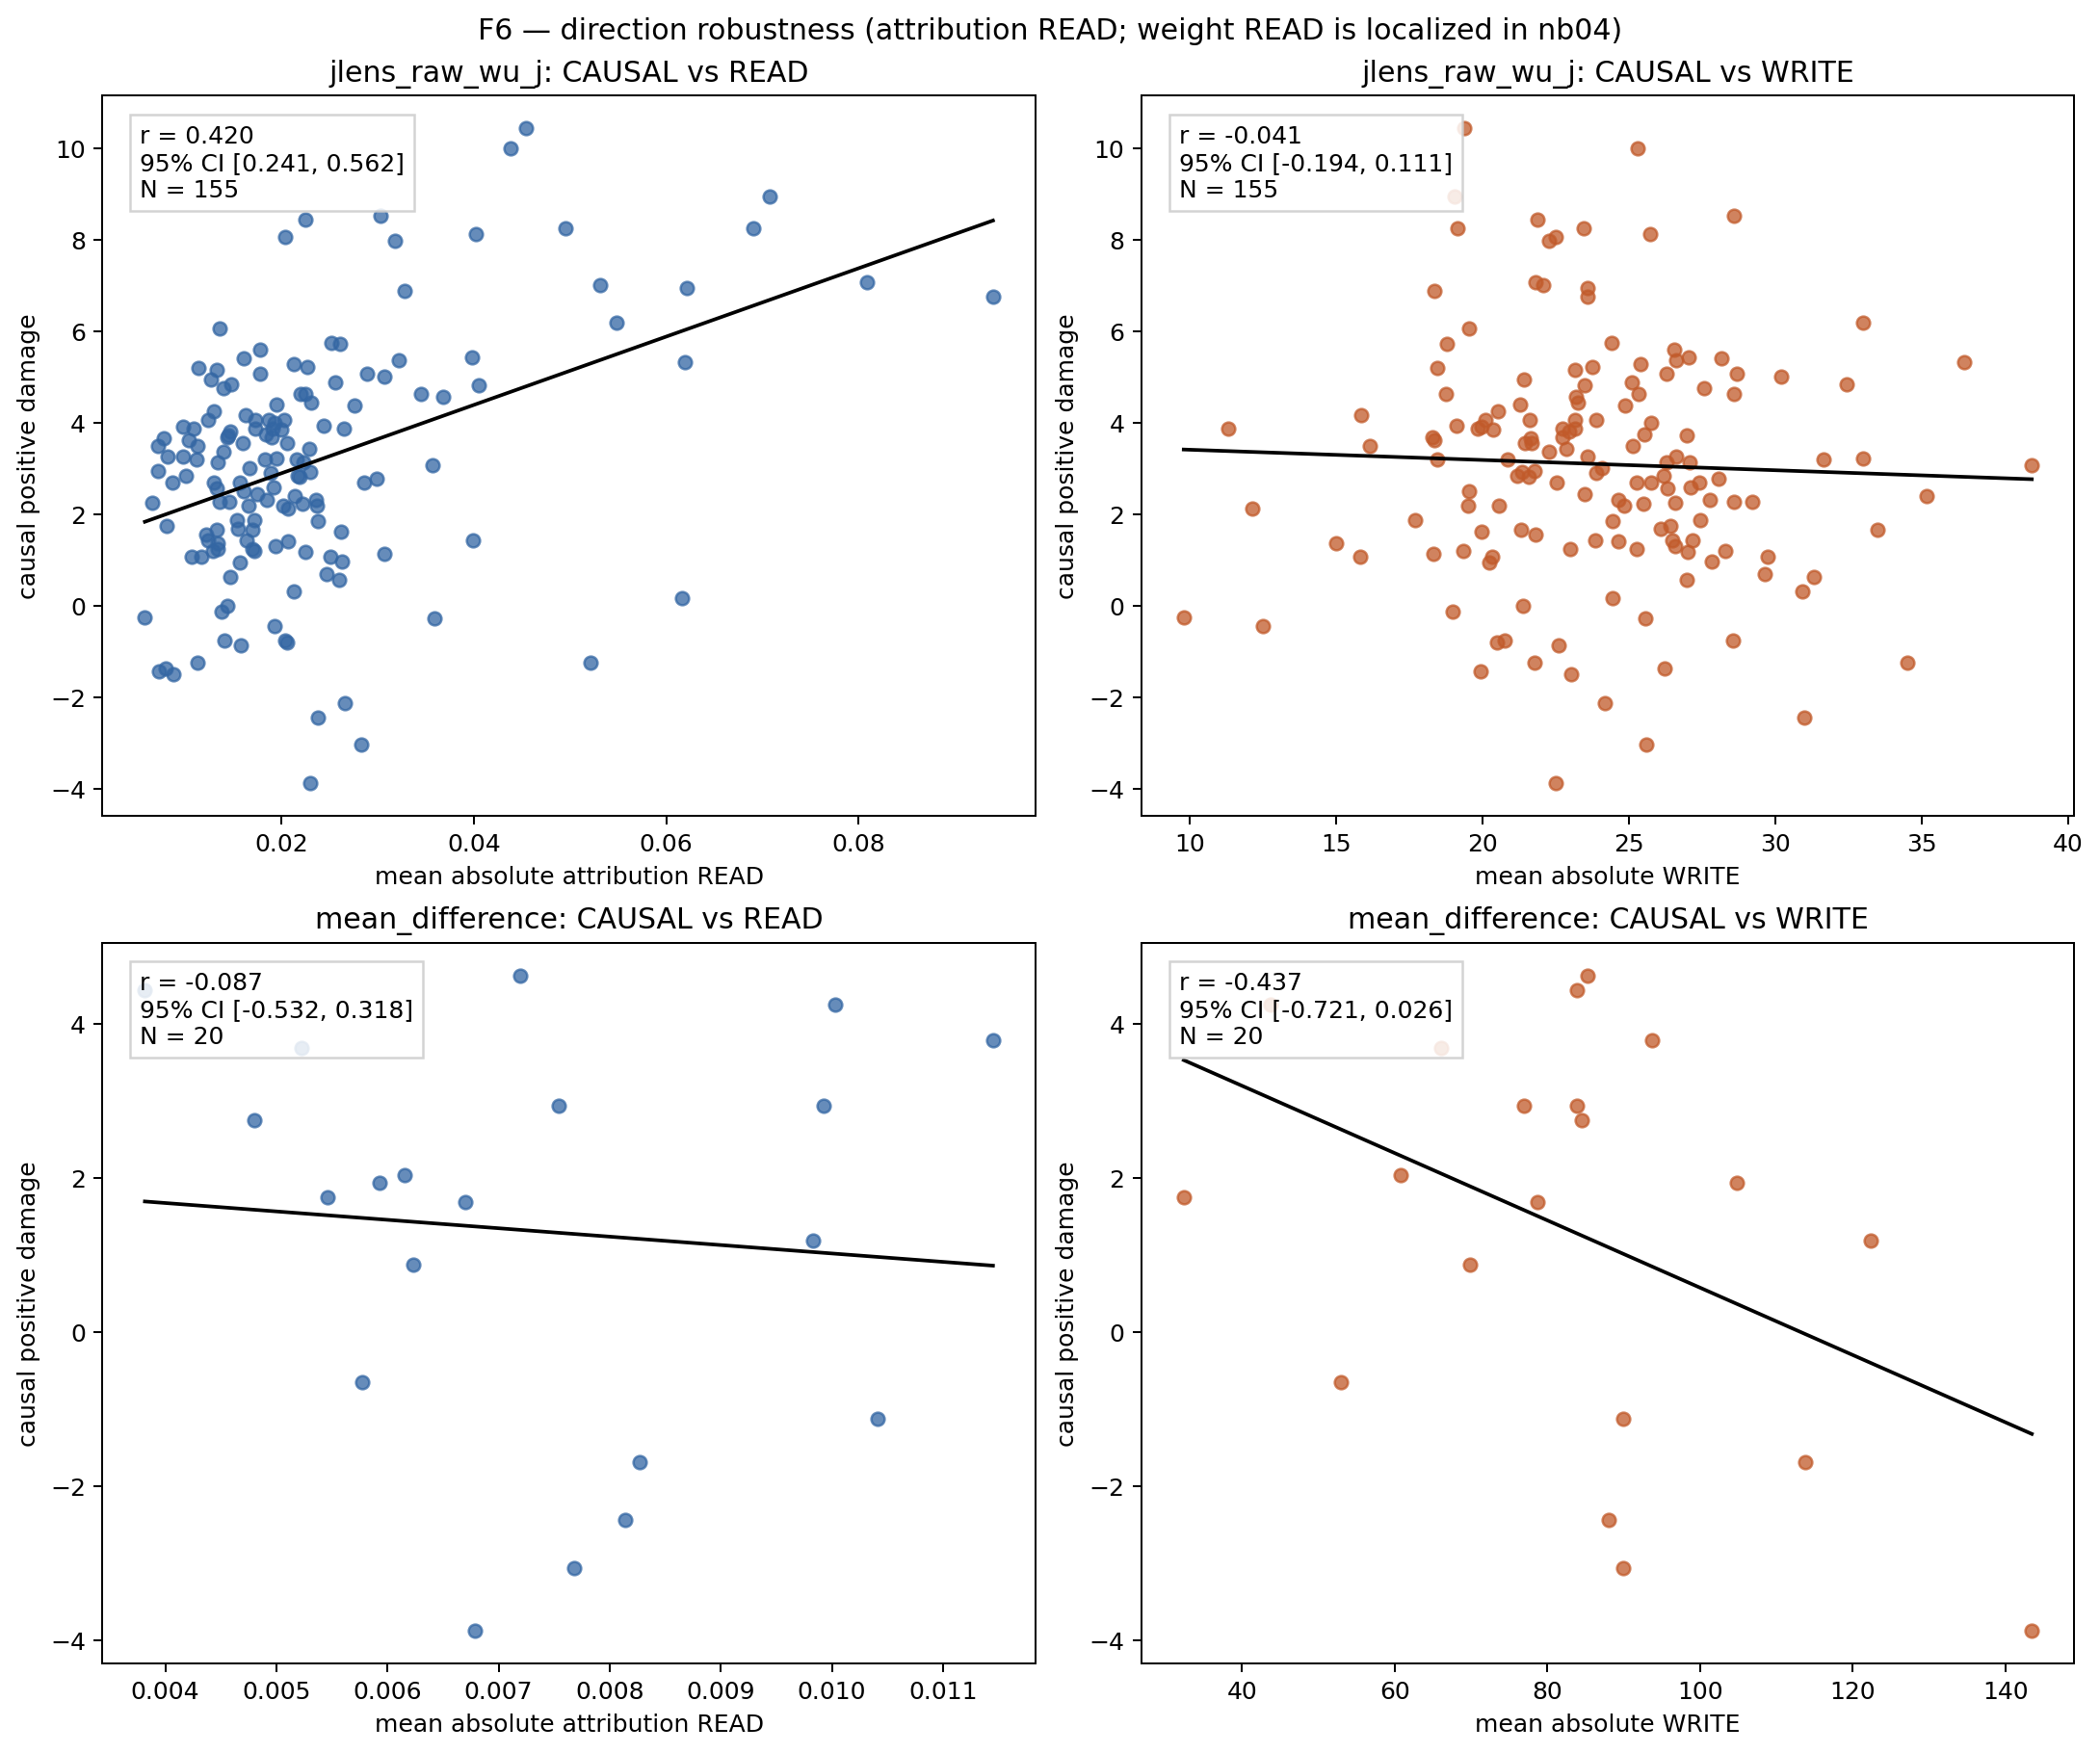

In [5]:
from IPython.display import Image, display

for figure_id in ('f1', 'f2', 'f6'):
    print(figure_id.upper(), twohop['figures'][figure_id])
    display(Image(filename=str(ROOT / twohop['figures'][figure_id])))

In [6]:
print(f"PHASE 02 {twohop['status']}")
print(f"CORPUS {twohop['corpus_criterion']['status']}: N={twohop['sample_counts']['n_clean_eligible']}")
print('No automatic P1 verdict: effect estimates and CIs are carried to notebook 08.')
if prior['gates']['g2']['status'] != 'PASS':
    print('LIMITATION: Qwen-7B failed the strict known-answer workspace gate; do not treat this scale as confirmatory.')
if prior['concept_vectors']['status'] != 'PASS':
    print('LIMITATION: MD directions failed two frozen validation criteria; MD robustness is diagnostic only.')

PHASE 02 COMPUTED
CORPUS PASS: N=155
No automatic P1 verdict: effect estimates and CIs are carried to notebook 08.
LIMITATION: Qwen-7B failed the strict known-answer workspace gate; do not treat this scale as confirmatory.
LIMITATION: MD directions failed two frozen validation criteria; MD robustness is diagnostic only.
